In [5]:
!apt-get update
!apt-get install -y libopencv-dev build-essential cmake

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Hit:9 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:10 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Fetched 3,917 B in 1s (4,510 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependen

In [6]:
%%writefile main.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>

int main() {
    std::cout << "OpenCV Versiyonu: " << CV_VERSION << std::endl;

    // Colab GPU Bağlantı Kontrolü
    int deviceCount = 0;
    cudaError_t error = cudaGetDeviceCount(&deviceCount);

    if (error == cudaSuccess && deviceCount > 0) {
        std::cout << "Başarılı! Colab GPU (CUDA) Algılandı. Cihaz Sayısı: " << deviceCount << std::endl;
    } else {
        std::cout << "CUDA Cihazı Bulunamadı veya GPU Aktif Edilmedi!" << std::endl;
    }

    return 0;
}

Overwriting main.cpp


In [11]:
!g++ main.cpp -o app pkg-config --cflags --libs opencv4 -I/usr/local/cuda/include -L/usr/local/cuda/lib64 -lcudart
!./app

g++: error: unrecognized command-line option ‘--cflags’
g++: error: unrecognized command-line option ‘--libs’; did you mean ‘--libs=’?
/bin/bash: line 1: ./app: No such file or directory


görev 2 - 1.


--- Resim 1 Analizi (resim1.jpeg) ---
Orijinal Minimum Piksel Değeri: 92
Orijinal Maksimum Piksel Değeri: 249
Ölçeklendirilmiş Yeni Minimum: 0
Ölçeklendirilmiş Yeni Maksimum: 255


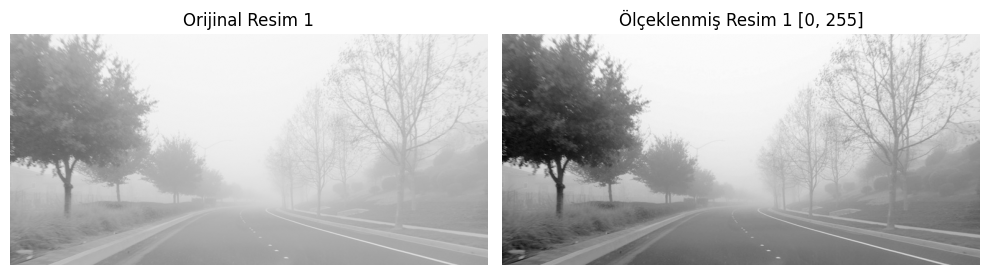


--- Resim 2 Analizi (resim 2.jpeg) ---
Orijinal Minimum Piksel Değeri: 0
Orijinal Maksimum Piksel Değeri: 237
Ölçeklendirilmiş Yeni Minimum: 0
Ölçeklendirilmiş Yeni Maksimum: 255


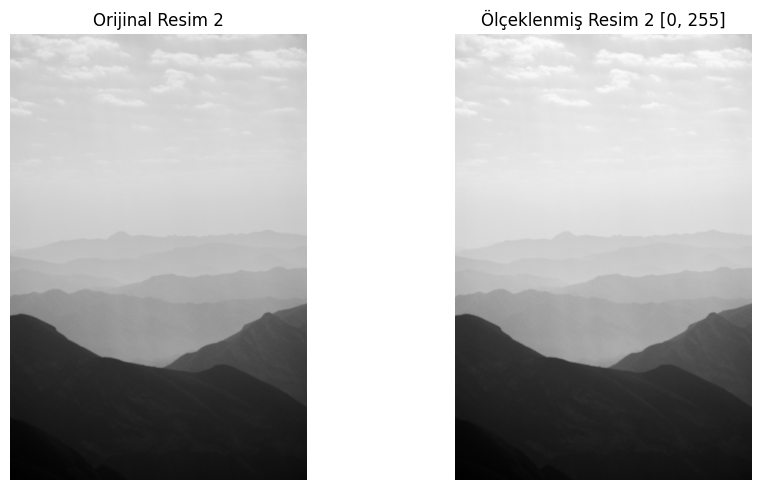

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_scale_image(image_path):
    # Görüntüyü tek kanallı (gri tonlamalı) olarak yükle
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Hata: Görüntü yüklenemedi! Yol: {image_path}")
        return None, None, None

    # Görüntüdeki min ve max değerleri bul
    min_val = np.min(img)
    max_val = np.max(img)

    # Doğrusal ölçekleme işlemi: (I - min) / (max - min) * 255
    # Paydanın sıfır olmasını engellemek için kontrol ekliyoruz
    if max_val - min_val > 0:
        scaled_img = ((img - min_val) / (max_val - min_val) * 255.0).astype(np.uint8)
    else:
        scaled_img = np.zeros_like(img)

    return img, scaled_img, (min_val, max_val)

# Resimleri işle
paths = ['/content/resim1.jpeg', '/content/resim 2.jpeg']

for i, path in enumerate(paths, start=1):
    orig, scaled, min_max = process_and_scale_image(path)
    if orig is not None:
        print(f"\n--- Resim {i} Analizi ({path.split('/')[-1]}) ---")
        print(f"Orijinal Minimum Piksel Değeri: {min_max[0]}")
        print(f"Orijinal Maksimum Piksel Değeri: {min_max[1]}")
        print(f"Ölçeklendirilmiş Yeni Minimum: {np.min(scaled)}")
        print(f"Ölçeklendirilmiş Yeni Maksimum: {np.max(scaled)}")

        # Görselleştirme
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(orig, cmap='gray', vmin=0, vmax=255)
        plt.title(f'Orijinal Resim {i}')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(scaled, cmap='gray', vmin=0, vmax=255)
        plt.title(f'Ölçeklenmiş Resim {i} [0, 255]')
        plt.axis('off')

        plt.tight_layout()
        plt.show()